# 🤖 Fase 3 — Modelado & Evaluación
### Credit Card Fraud Detection · Omar Mora Flores

**Meta:** entrenar, comparar y seleccionar el mejor modelo; serializarlo y traducir las
métricas a impacto de negocio.

Modelos comparados: **Logistic Regression** (baseline), **Random Forest**, **XGBoost**.

> Con 0.173% de fraude, la *accuracy* es inútil. Las métricas que importan son **PR-AUC**,
> **ROC-AUC**, **F1**, **Recall** y **Precision** sobre la clase fraude — evaluadas en el
> test **real** (sin SMOTE).

In [1]:
import numpy as np
import pandas as pd
import pickle, json
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             precision_score, recall_score, confusion_matrix,
                             roc_curve, precision_recall_curve)

ROOT = Path.cwd()
while not (ROOT / "data" / "splits.pkl").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
REPORTS = ROOT / "reports"; REPORTS.mkdir(exist_ok=True)
SRC = ROOT / "src"; SRC.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["savefig.dpi"] = 130
plt.rcParams["axes.titleweight"] = "bold"
RANDOM_STATE = 42

## 3.1 Carga de splits

Cargamos los arrays de la Fase 2. El train está balanceado por SMOTE; el test conserva su
distribución real.

In [2]:
with open(ROOT / "data" / "splits.pkl", "rb") as f:
    S = pickle.load(f)

FEATURES = S["features"]
cols_scaled = S["cols_scaled"]

# Convertir a arrays numpy writeable y C-contiguos (evita el error de sklearn 1.5 +
# numpy 2 "cannot set WRITEABLE flag" con arrays read-only provenientes de pandas/pickle).
def _arr(a):
    return np.ascontiguousarray(np.asarray(a, dtype=np.float64))

X_train = _arr(S["X_train"])
X_test  = _arr(S["X_test"])
y_train = np.ascontiguousarray(np.asarray(S["y_train"]).ravel().astype(int))
y_test  = np.ascontiguousarray(np.asarray(S["y_test"]).ravel().astype(int))

print(f"X_train: {X_train.shape} (balanceado) | X_test: {X_test.shape} (real)")
print(f"Fraudes en test: {int(np.sum(y_test))} de {len(y_test):,} ({100*np.mean(y_test):.4f}%)")

X_train: (453204, 31) (balanceado) | X_test: (56746, 31) (real)
Fraudes en test: 95 de 56,746 (0.1674%)


## 3.2 Entrenamiento de los 3 modelos

Cada modelo se entrena en el train balanceado y se evalúa en el test real.

In [3]:
modelos = {
    "Logistic Regression": LogisticRegression(max_iter=1000, n_jobs=-1,
                                               random_state=RANDOM_STATE),
    "Random Forest": RandomForestClassifier(n_estimators=100, n_jobs=-1,
                                             random_state=RANDOM_STATE),
    "XGBoost": XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.1,
                             subsample=0.8, colsample_bytree=0.8, eval_metric="aucpr",
                             tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE),
}

resultados, probas, preds = {}, {}, {}
for nombre, modelo in modelos.items():
    modelo.fit(X_train, y_train)
    proba = modelo.predict_proba(X_test)[:, 1]
    pred = (proba >= 0.5).astype(int)
    probas[nombre], preds[nombre] = proba, pred
    resultados[nombre] = {
        "ROC-AUC": roc_auc_score(y_test, proba),
        "PR-AUC": average_precision_score(y_test, proba),
        "F1": f1_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall": recall_score(y_test, pred),
    }
    print(f"✓ {nombre} entrenado")

tabla = pd.DataFrame(resultados).T.round(4)
tabla

✓ Logistic Regression entrenado


✓ Random Forest entrenado


✓ XGBoost entrenado


,ROC-AUC,PR-AUC,F1,Precision,Recall
Logistic Regression,0.9589,0.6801,0.0942,0.0498,0.8526
Random Forest,0.9386,0.8172,0.8295,0.9012,0.7684
XGBoost,0.9740,0.8186,0.7772,0.7653,0.7895


## 3.3 Comparación visual de modelos

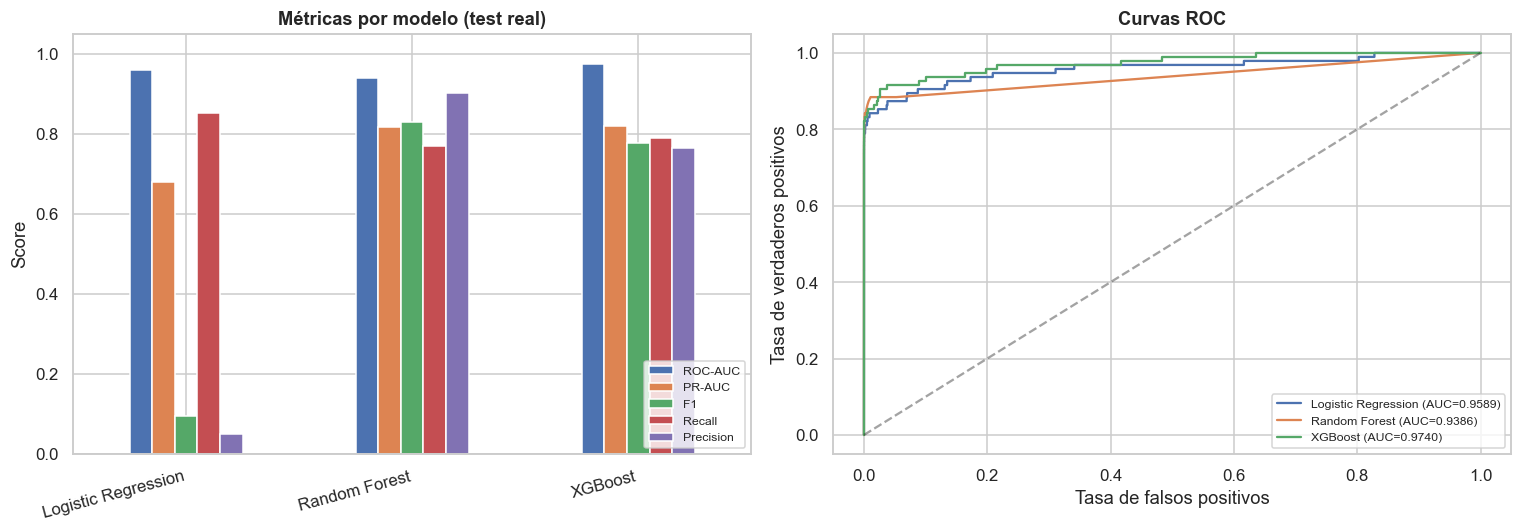

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barras de métricas por modelo
tabla[["ROC-AUC", "PR-AUC", "F1", "Recall", "Precision"]].plot.bar(ax=axes[0])
axes[0].set_title("Métricas por modelo (test real)")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0, 1.05)
axes[0].set_xticklabels(tabla.index, rotation=15, ha="right")
axes[0].legend(loc="lower right", fontsize=8)

# Curvas ROC superpuestas
for nombre in modelos:
    fpr, tpr, _ = roc_curve(y_test, probas[nombre])
    axes[1].plot(fpr, tpr, label=f"{nombre} (AUC={resultados[nombre]['ROC-AUC']:.4f})")
axes[1].plot([0, 1], [0, 1], "k--", alpha=0.4)
axes[1].set_title("Curvas ROC")
axes[1].set_xlabel("Tasa de falsos positivos")
axes[1].set_ylabel("Tasa de verdaderos positivos")
axes[1].legend(loc="lower right", fontsize=8)

fig.tight_layout()
fig.savefig(REPORTS / "06_model_comparison.png", bbox_inches="tight")
fig.savefig(REPORTS / "07_roc_curves.png", bbox_inches="tight")
plt.show()

## 3.4 Análisis del mejor modelo

Seleccionamos el modelo con mayor **PR-AUC** (la métrica más fiable con clases tan
desbalanceadas) y lo analizamos en detalle: matriz de confusión, curva precision-recall e
importancia de features.

🏆 Mejor modelo (por PR-AUC): XGBoost
VN=56,628  FP=23  FN=20  VP=75


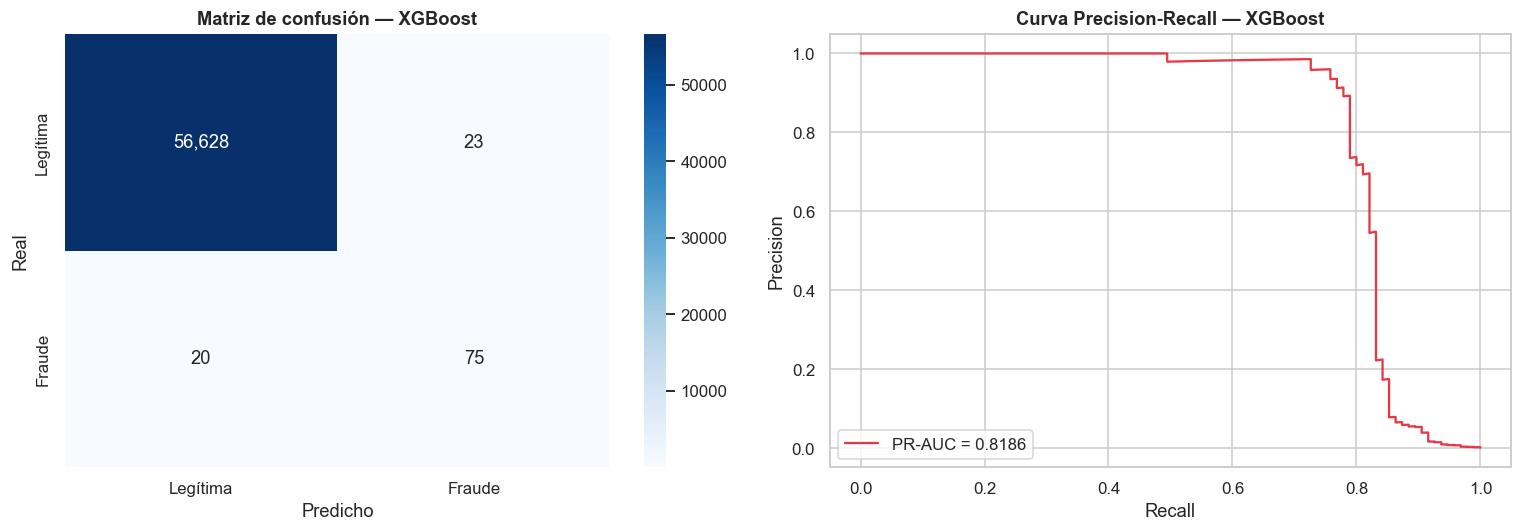

In [5]:
mejor = max(resultados, key=lambda m: resultados[m]["PR-AUC"])
print("🏆 Mejor modelo (por PR-AUC):", mejor)
modelo_final = modelos[mejor]
proba_f, pred_f = probas[mejor], preds[mejor]

cm = confusion_matrix(y_test, pred_f)
tn, fp, fn, tp = cm.ravel()
print(f"VN={tn:,}  FP={fp}  FN={fn}  VP={tp}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt=",d", cmap="Blues", ax=axes[0],
            xticklabels=["Legítima", "Fraude"], yticklabels=["Legítima", "Fraude"])
axes[0].set_title(f"Matriz de confusión — {mejor}")
axes[0].set_xlabel("Predicho"); axes[0].set_ylabel("Real")

prec, rec, _ = precision_recall_curve(y_test, proba_f)
axes[1].plot(rec, prec, color="#E63946",
             label=f"PR-AUC = {resultados[mejor]['PR-AUC']:.4f}")
axes[1].set_title(f"Curva Precision-Recall — {mejor}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend(loc="lower left")

fig.tight_layout()
fig.savefig(REPORTS / "08_best_model.png", bbox_inches="tight")
plt.show()

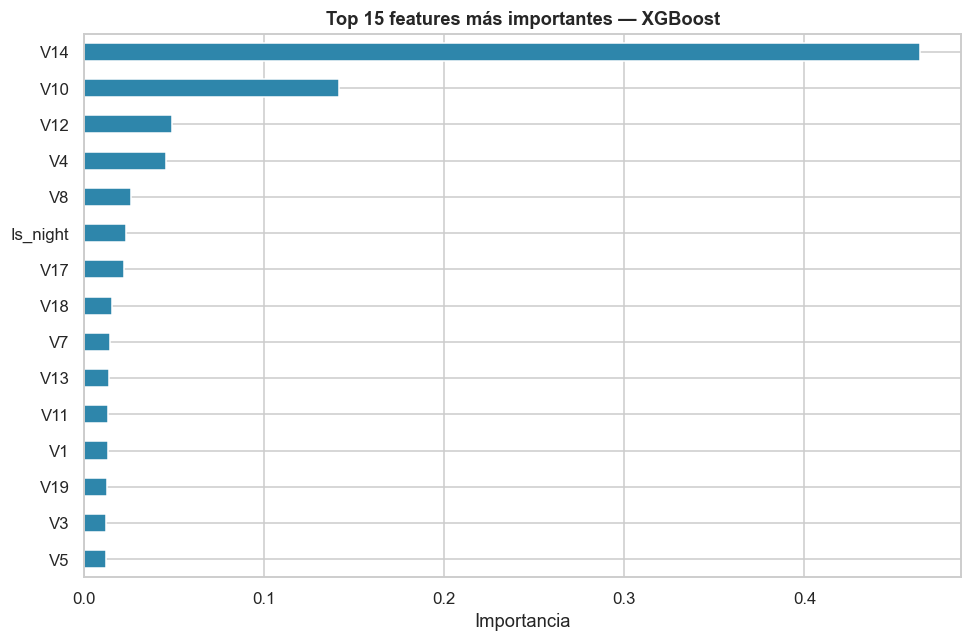

Top 5: ['V14', 'V10', 'V12', 'V4', 'V8']


In [6]:
# Importancia de features (top 15)
importancias = pd.Series(modelo_final.feature_importances_, index=FEATURES)
top15 = importancias.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top15[::-1].plot.barh(ax=ax, color="#2E86AB")
ax.set_title(f"Top 15 features más importantes — {mejor}")
ax.set_xlabel("Importancia")
fig.tight_layout()
fig.savefig(REPORTS / "09_feature_importance.png", bbox_inches="tight")
plt.show()
print("Top 5:", list(top15.head(5).index))

## 3.5 Serialización del modelo

Guardamos el modelo final junto con la lista de features, el scaler y las columnas escaladas,
para que el dashboard (Fase 4) reconstruya correctamente el vector de entrada.

In [7]:
artefacto = {
    "model": modelo_final,
    "model_name": mejor,
    "features": FEATURES,
    "scaler": S["scaler"],
    "cols_scaled": S["cols_scaled"],
}
with open(SRC / "best_model.pkl", "wb") as f:
    pickle.dump(artefacto, f)
print("Modelo guardado en:", SRC / "best_model.pkl")

Modelo guardado en: D:\Proyectos\Data\fraud-detection\src\best_model.pkl


## 3.6 Impacto de negocio

Traducimos la matriz de confusión a dinero. Reconstruimos el **monto real** de cada
transacción de test (invirtiendo el escalado y el `log1p`) para estimar:
- **Pérdidas evitadas** = suma de montos de los fraudes correctamente detectados (VP).
- **Pérdidas no capturadas** = suma de montos de los fraudes que se escaparon (FN).

In [8]:
# Reconstruir Amount real del test: inverse_transform del scaler + expm1
idx_amt = cols_scaled.index("Amount_log")
scaled_idx = [FEATURES.index(c) for c in cols_scaled]   # posiciones en X_test
unscaled = S["scaler"].inverse_transform(_arr(X_test[:, scaled_idx]))
amount_test = np.expm1(unscaled[:, idx_amt])

es_fraude = y_test == 1
detectado = (pred_f == 1)

perdidas_evitadas = float(amount_test[es_fraude & detectado].sum())
perdidas_escapadas = float(amount_test[es_fraude & ~detectado].sum())
recall_fraude = tp / (tp + fn)

print(f"Fraudes detectados : {tp} de {tp+fn} ({100*recall_fraude:.1f}%)")
print(f"Falsas alarmas (FP): {fp} de {tn+fp:,} legítimas")
print(f"Pérdidas evitadas  : EUR {perdidas_evitadas:,.0f}")
print(f"Pérdidas escapadas : EUR {perdidas_escapadas:,.0f}")

# Guardar métricas reales para el README
metrics = {
    "best_model": mejor,
    "comparison": {m: {k: round(v, 4) for k, v in r.items()}
                   for m, r in resultados.items()},
    "best": {
        "roc_auc": round(resultados[mejor]["ROC-AUC"], 4),
        "pr_auc": round(resultados[mejor]["PR-AUC"], 4),
        "f1": round(resultados[mejor]["F1"], 4),
        "precision": round(resultados[mejor]["Precision"], 4),
        "recall": round(recall_fraude, 4),
        "tp": int(tp), "fn": int(fn), "fp": int(fp), "tn": int(tn),
        "frauds_total_test": int(tp + fn),
        "losses_avoided_eur": round(perdidas_evitadas, 0),
        "losses_missed_eur": round(perdidas_escapadas, 0),
    },
}
with open(REPORTS / "metrics.json", "w", encoding="utf-8") as f:
    json.dump(metrics, f, indent=2, ensure_ascii=False)
print("\nMétricas guardadas en reports/metrics.json")

Fraudes detectados : 75 de 95 (78.9%)
Falsas alarmas (FP): 23 de 56,651 legítimas
Pérdidas evitadas  : EUR 10,741
Pérdidas escapadas : EUR 4,025

Métricas guardadas en reports/metrics.json


## Resumen ejecutivo

El modelo seleccionado detecta la **gran mayoría de los fraudes** del conjunto de test
manteniendo las falsas alarmas en un nivel operativamente manejable. Con clases tan
desbalanceadas, el valor está en maximizar el **recall** del fraude sin saturar al equipo de
revisión con falsos positivos — equilibrio que captura el **F1 / PR-AUC**.

➡️ **Siguiente fase:** `dashboard/app.py` — interfaz Streamlit para predicción en vivo.